# Fundamentals

(This notebook documents my practice of statistical methods. While I have taken care going through the code, there may be errors or inefficiencies. This is the nature of learning, and I will be sure to keep updating this notebook as my understanding develops)

Generate random data:

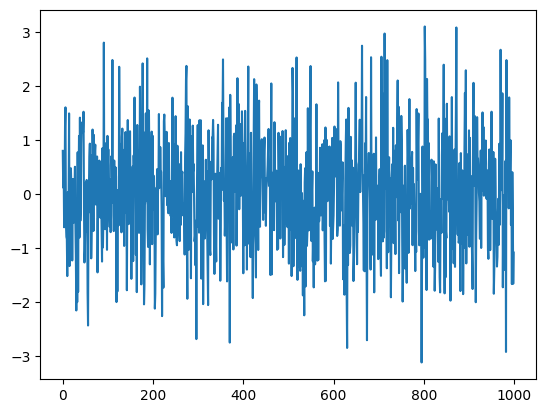

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.random.normal(0, 1, 1000)
plt.plot(X)

Plot Series:

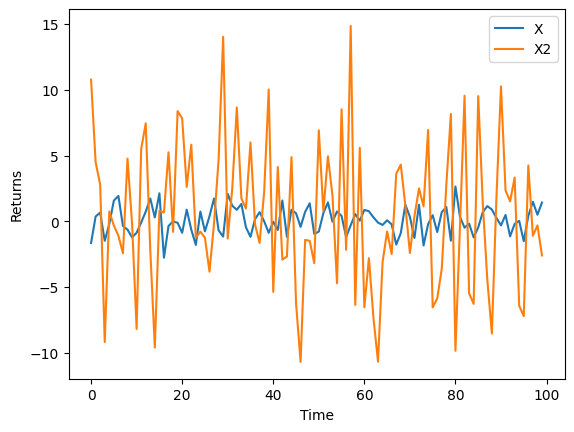

In [2]:
import numpy as np

X = np.random.normal(0, 1, 100)
X2 = np.random.normal(0, 5, 100)

plt.plot(X)
plt.plot(X2)
plt.xlabel("Time")
plt.ylabel("Returns")
plt.legend(["X", "X2"])

Basic Visualisation:

0.01678233038046865
1.0097609656728226


(array([  5.,   4.,   6.,  20.,  43.,  61.,  97., 119., 117., 146., 121.,
         84.,  74.,  38.,  34.,  16.,  10.,   4.,   0.,   1.]),
 array([-3.07049979, -2.73443553, -2.39837128, -2.06230702, -1.72624277,
        -1.39017852, -1.05411426, -0.71805001, -0.38198576, -0.0459215 ,
         0.29014275,  0.62620701,  0.96227126,  1.29833551,  1.63439977,
         1.97046402,  2.30652828,  2.64259253,  2.97865678,  3.31472104,
         3.65078529]),
 <BarContainer object of 20 artists>)

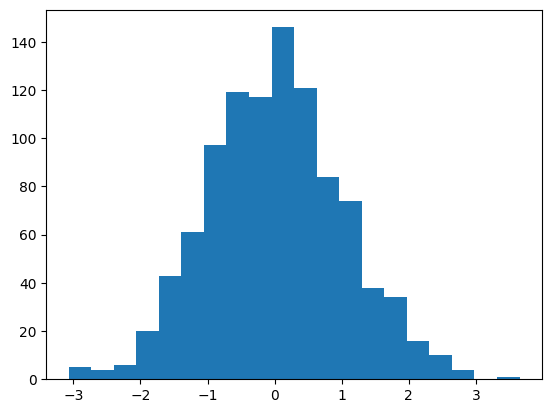

In [3]:
import numpy as np
import matplotlib.pyplot as plt


X = np.random.normal(0, 1, 1000)

print(np.mean(X))
print(np.std(X))

plt.hist(X, bins = 20)


Basic Normal Plot:

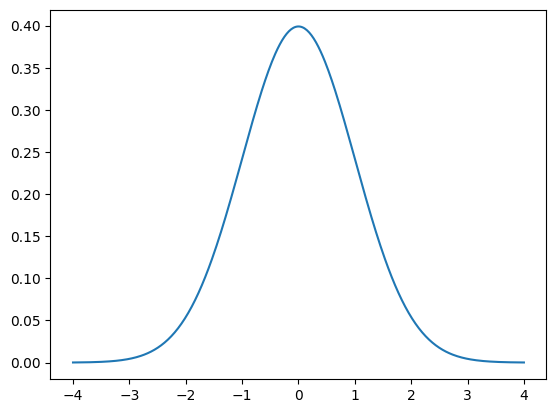

In [4]:
x = np.linspace(-4, 4, 400) # From -4 to 4, 400 elements
y = (1 / np.sqrt(2*np.pi)) * np.exp(-0.5 * x**2)

plt.plot(x, y)

Plot using scipy:

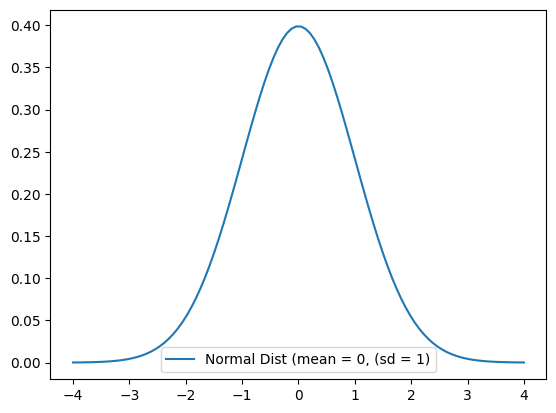

In [16]:
from scipy.stats import norm 
import matplotlib.pyplot as plt

mu = 0
sigma = 1

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100) # 100 elements, 4 standard deviations out is >99% of density 

y = norm.pdf(x, mu, sigma)

plt.plot(x, y, label = f"Normal Dist (mean = {mu}, (sd = {sigma})")
plt.legend()
# plt.savefig("")
plt.show()

Slicing Lists:

In [6]:
a = [6, 7, 8, 9, 10, 11]

print(a[:])
print(a[2:]) # Start at 3rd (0,1,2)
print(a[:4]) # Go up until 4th (noninclusive of actual 4th)
print(a[1:5:2]) # Index 1 start (second position) up to index 5 (noninclusive, up to index 4), gaps of 2
print(a[::-1]) # Reverse

[6, 7, 8, 9, 10, 11]
[8, 9, 10, 11]
[6, 7, 8, 9]
[7, 9]
[11, 10, 9, 8, 7, 6]


Random Data:

In [46]:
#import random

#random.random() # Uniform float in (0.0, 1.0)
#random.randint(a, b) # Integer in (a, b)
#random.uniform(a, b) # Float in (a, b)
#random.gauss(mu, sigma) # Gaussian Dist

#random.choice(seq) # Random Element
#random.sample(seq, k) # k unique elements

(array([1013.,  984.,  993., 1007.,  996., 1007.,  985.,  969., 1024.,
        1022.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

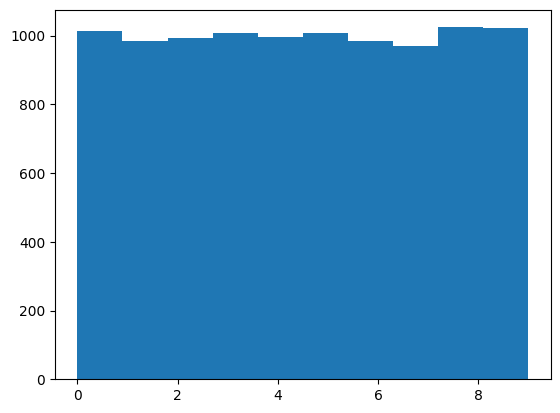

In [48]:
import random

int = []

for i in range(10000):
    int.append(random.randint(0, 9))

int; # Suppress display of array
plt.hist(int, bins = 10)


In [49]:
import random

seq = ["apple", "banana", "orange"]

print(random.choice(seq))
print(random.sample(seq, 2))


apple
['apple', 'orange']


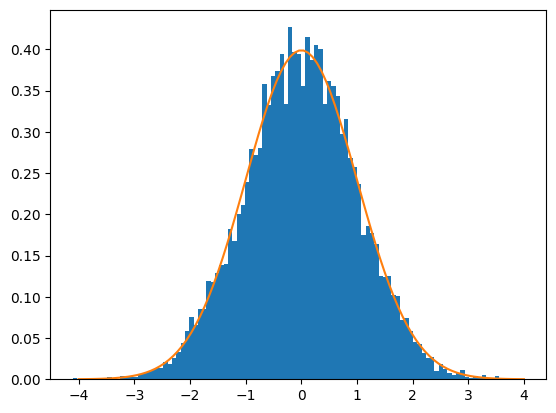

In [50]:
import random
import matplotlib.pyplot as plt

normal = []

for i in range(10000):
    normal.append(random.gauss(0, 1))

mu = 0
sigma = 1

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100) # 100 elements, 4 standard deviations out is >99% of density 

y = norm.pdf(x, mu, sigma)

plt.hist(normal, bins = 100, density = True) # Without density = True, we just display the counts for each obs. For a proper overlay (to match y-scale) we need density NOT counts
plt.plot(x, y);

Using Yahoo Finance, creating log price differences and percentage changes:

[*********************100%***********************]  1 of 1 completed

Ticker          TSLA
Date                
2010-06-29  1.592667
2010-06-30  1.588667
2010-07-01  1.464000
2010-07-02  1.280000
2010-07-06  1.074000


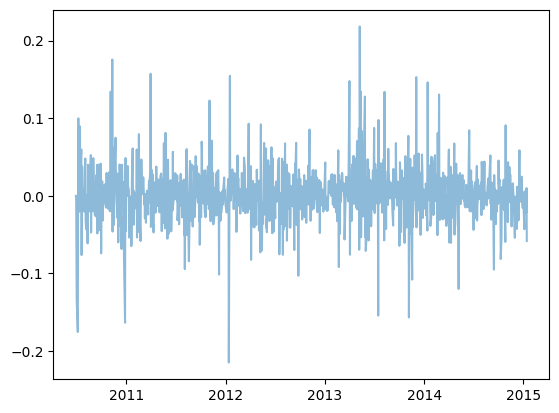

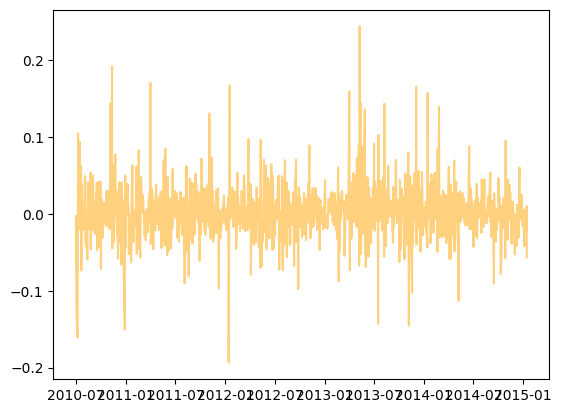

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

data = yf.download(["TSLA"], start="2005-01-01", end="2015-01-15")
closing_prices = data["Close"] 
print(closing_prices.head())

returns = np.log(closing_prices).diff().fillna(0) # LOG change, additive over time
returns2 = closing_prices.pct_change().dropna()

plt.figure()
plt.plot(returns, alpha = 0.5);

plt.figure()
plt.plot(returns2, color = "orange", alpha = 0.5);
# Almost the same, log price differences are approximately equal to returns for small price changes

$$

\log(\frac{P_{t+1}}{P_{t}}) = \log(1+r) \approx r

$$

Return Series Simulation, cumulative normal shocks:

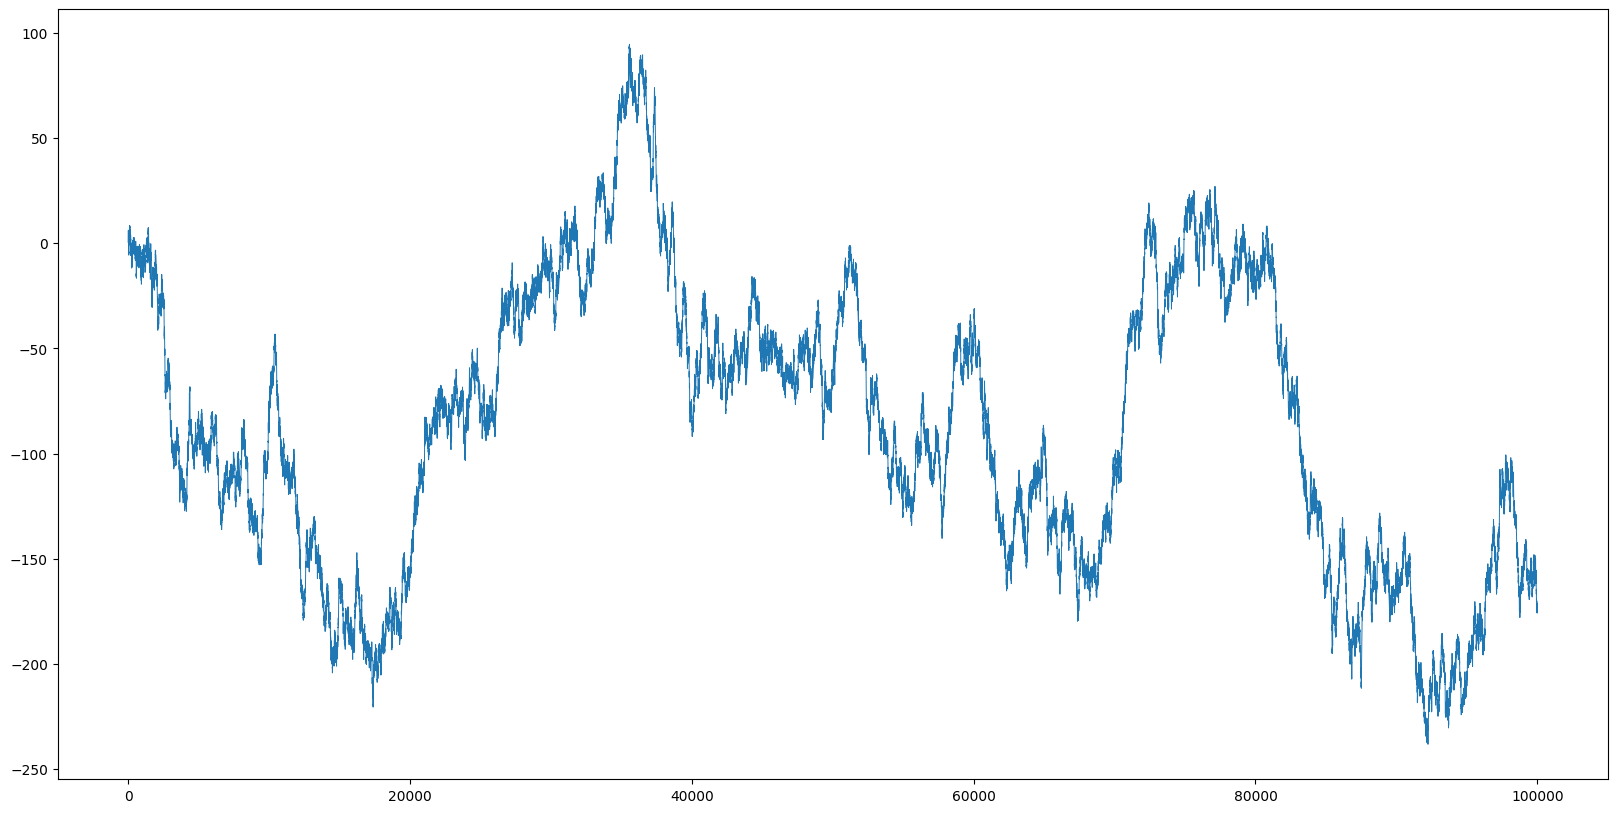

In [2]:
import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

l = 100_000

ret = np.random.normal(0, 1, 100_000)

r = pd.Series(np.cumsum(ret))
plt.figure(figsize=(20,10))
plt.plot(r, lw = 0.7);


Reminiscent of Brownian Motion, cumulative sum of normals. As we allow more and more normals we get the fimiliar "jagged" shape. As our time step tends to 0, our process converges to GBM.

Plot Y as a linear function of X with some noise:

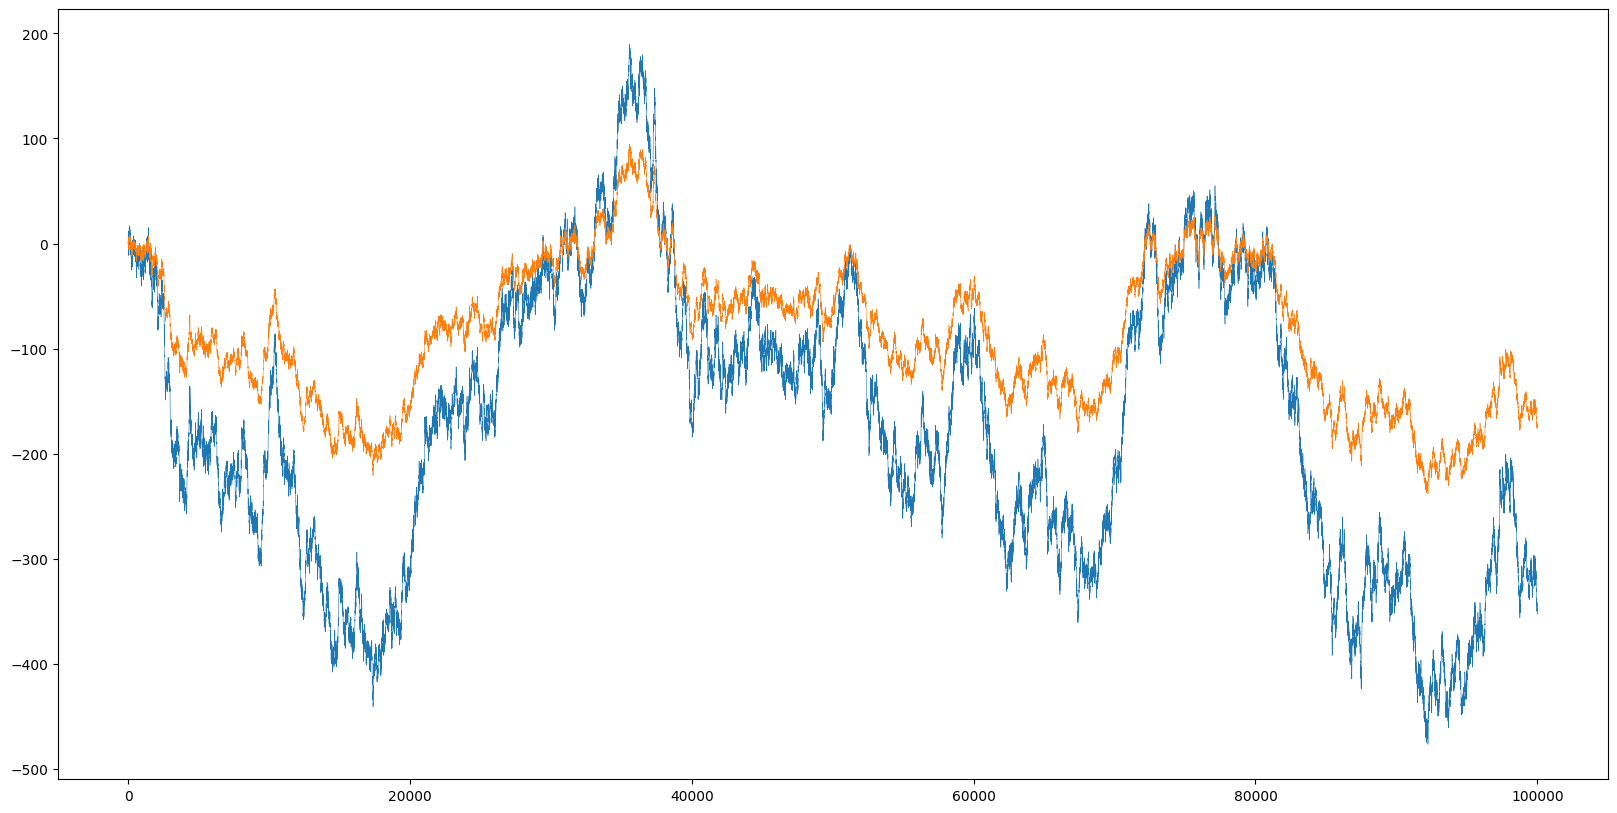

In [3]:
noise = np.random.normal(0, 1, l);
y = 2*r + noise

plt.figure(figsize=(20,10))
plt.plot(y, lw = 0.4)
plt.plot(r, lw = 0.4)

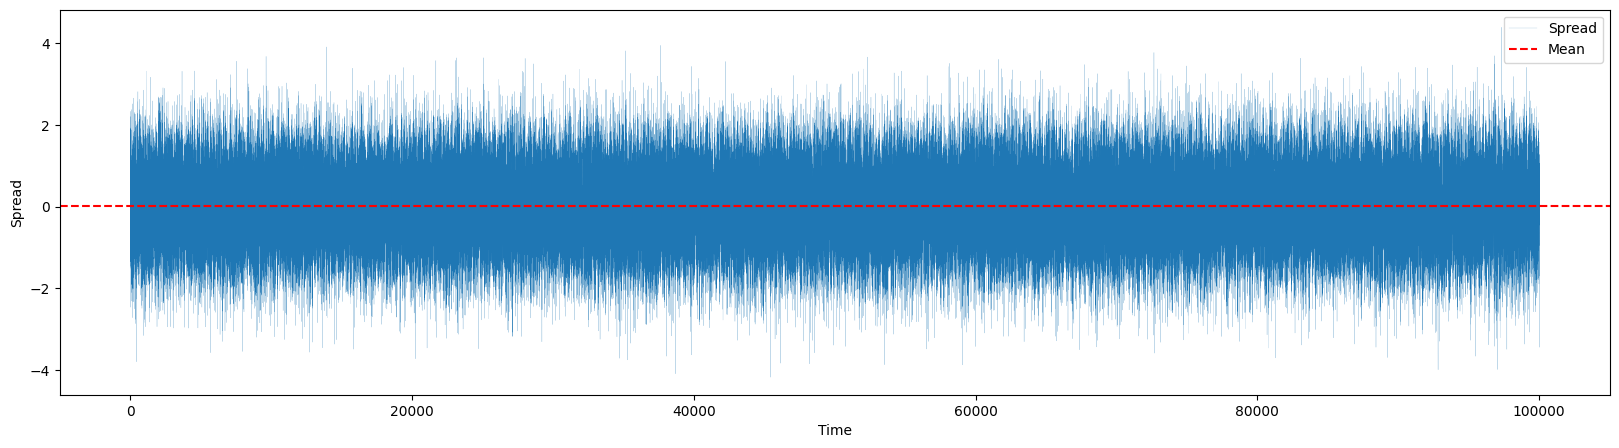

In [4]:
plt.figure(figsize=(20,5))
plt.plot(y - 2*r, lw = 0.1)
plt.axhline((y - 2*r).mean(), color = "red", linestyle = "--")
plt.xlabel("Time")
plt.ylabel("Spread")
plt.legend(["Spread", "Mean"])

Testing for Cointegration:

In [85]:
zscore, pvalue, crit = coint(y,r)
print(zscore) # Z score
print(pvalue) # P value
print(crit) # Gives 1%, 5% and 10% thresholds
print(y.corr(r))

if abs(crit[0]) < abs(zscore):
    print("Significant at 1%")
elif abs(crit[1]) < abs(zscore):
    print("Significant at 5%")
elif abs(crit[2]) < abs(zscore):
    print("Significant at 10%")
else:
    print("Not Significant")

-317.29951085235194
0.0
[-3.89654952 -3.3361911  -3.04449241]
0.9999713988489773
Significant at 10%


Covariance and Correlation:

In [ ]:
import numpy as np

X = np.random.normal(0, 1, 1000)
epsilon = np.random.normal(0, 3, len(X))

Y = 3*X + epsilon
product = (X - np.mean(X))*(Y - np.mean(Y))
cov = np.mean(product)
corr = (cov)/(np.std(X)*np.std(Y))

print(cov)
print(corr)

2.891440226317581
0.6963265735025034


$$

E([X - E[X]][Y - E[Y]])

$$

CLT

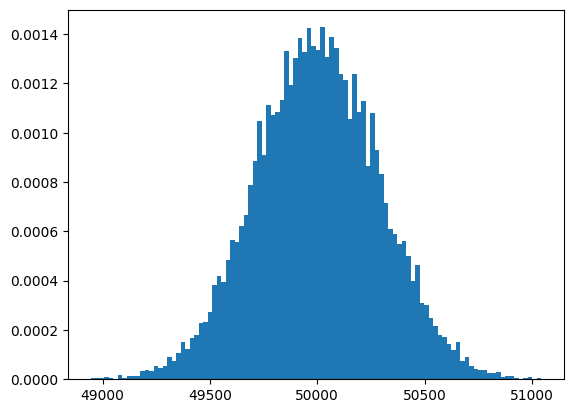

In [12]:
import random
import numpy as np
import matplotlib.pyplot as plt

l = 10_000


arrays = np.random.uniform(0, 10, (10_000, l)) # Numpy arrays have a size parameter, for (x, y) vectors have length x and there are y vectors

rowsum = np.sum(arrays, axis = 1) # Axis = 1 refers to COLUMNS, collapsing sideways

plt.figure()
plt.hist(rowsum, density = True, bins = 100);



CLT in action. Expectation of sum of random variables. 